# MidTerm Project

Rich Fox <p>
ITAI 1371<p>
Spring 2026<p>

Trying to identify Heart Disease using a dataset of healthcare data.

### The 6-Step ML Workflow:
1. **Data Preparation**: Clean and prepare the data
2. **Feature Selection**: Choose relevant input variables
3. **Data Splitting**: Separate training and testing data
4. **Model Training**: Teach the algorithm using training data
5. **Model Evaluation**: Test performance on unseen data
6. **Model Interpretation**: Understand what the model learned

## 1. Data Preparation
Clean and prepare the data


In [1]:
# Making sure we have the imbalanced-learn library installed for handling imbalanced datasets

#  !pip install imbalanced-learn

In [2]:
# Setting up the enviroment. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC



In [3]:
# Loading the data

# Path to the file you downloaded and unzipped
file_path = r"C:\School Git\ITAI_ML_FirstRepo_RichFox\Midterm Project\heart_2022_with_nans.csv"

# Importing the dataset into RAM
df = pd.read_csv(file_path)

# Looking at the columns and such.
print("First 5 records:")
print(df.head())

# print("--- Basic Info ---")
# df.info()


First 5 records:
     State     Sex GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
0  Alabama  Female     Very good                 0.0               0.0   
1  Alabama  Female     Excellent                 0.0               0.0   
2  Alabama  Female     Very good                 2.0               3.0   
3  Alabama  Female     Excellent                 0.0               0.0   
4  Alabama  Female          Fair                 2.0               0.0   

                                     LastCheckupTime PhysicalActivities  \
0  Within past year (anytime less than 12 months ...                 No   
1                                                NaN                 No   
2  Within past year (anytime less than 12 months ...                Yes   
3  Within past year (anytime less than 12 months ...                Yes   
4  Within past year (anytime less than 12 months ...                Yes   

   SleepHours RemovedTeeth HadHeartAttack  ... HeightInMeters  \
0         8.0         

In [4]:
# Let's look at the missing values
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

#Checking values values
print(df['Sex'].value_counts()) 
print(df['TetanusLast10Tdap'].value_counts()) 
print(df['GeneralHealth'].value_counts())
print(df['LastCheckupTime'].value_counts())
print(df['RemovedTeeth'].value_counts())
print(df['SmokerStatus'].value_counts())
print(df['ECigaretteUsage'].value_counts())
print(df['RaceEthnicityCategory'].value_counts())
print(df['AgeCategory'].value_counts())



--- Missing Values Before Cleaning ---
State                            0
Sex                              0
GeneralHealth                 1198
PhysicalHealthDays           10927
MentalHealthDays              9067
LastCheckupTime               8308
PhysicalActivities            1093
SleepHours                    5453
RemovedTeeth                 11360
HadHeartAttack                3065
HadAngina                     4405
HadStroke                     1557
HadAsthma                     1773
HadSkinCancer                 3143
HadCOPD                       2219
HadDepressiveDisorder         2812
HadKidneyDisease              1926
HadArthritis                  2633
HadDiabetes                   1087
DeafOrHardOfHearing          20647
BlindOrVisionDifficulty      21564
DifficultyConcentrating      24240
DifficultyWalking            24012
DifficultyDressingBathing    23915
DifficultyErrands            25656
SmokerStatus                 35462
ECigaretteUsage              35660
ChestScan       

#### In this next part, classifing everything to a numeric value.

In [5]:
# Create the HeartDisease column
# Condition: If HadHeartAttack is 'Yes' OR HadStroke is 'Yes', result is 'Yes', otherwise 'No'
df['HeartDisease'] = np.where(
    (df['HadHeartAttack'] == 'Yes') | (df['HadStroke'] == 'Yes'), 
    1, 
    0
)
# Since I am doing my ML trying to classisfy Heart Disease, I am dropping all the rows that are nan for Heart Attack and Stroke, because I can't be sure if they have heart disease or not.
df.dropna(subset=['HadHeartAttack'], inplace=True)
df.dropna(subset=['HadStroke'], inplace=True)

## Verify the new column
# print(df[['HadHeartAttack', 'HadStroke', 'HeartDisease']].head(10))

# Convert classes to numeric: Yes -> 1, No -> 0
df['PhysicalActivities'] = df['PhysicalActivities'].map({'Yes': 1, 'No': 0})
df['AlcoholDrinkers'] = df['AlcoholDrinkers'].map({'Yes': 1, 'No': 0})
df['HIVTesting'] = df['HIVTesting'].map({'Yes': 1, 'No': 0})
df['FluVaxLast12'] = df['FluVaxLast12'].map({'Yes': 1, 'No': 0})
df['HighRiskLastYear'] = df['HighRiskLastYear'].map({'Yes': 1, 'No': 0, 'Tested positive using home test without a health professional' : 1})
df['CovidPos'] = df['CovidPos'].map({'Yes': 1, 'No': 0})
df['HadAngina'] = df['HadAngina'].map({'Yes': 1, 'No': 0})
df['PneumoVaxEver'] = df['PneumoVaxEver'].map({'Yes': 1, 'No': 0})
df['HadSkinCancer'] = df['HadSkinCancer'].map({'Yes': 1, 'No': 0})
df['HadAsthma'] = df['HadAsthma'].map({'Yes': 1, 'No': 0})
df['HadCOPD'] = df['HadCOPD'].map({'Yes': 1, 'No': 0})
df['HadDepressiveDisorder'] = df['HadDepressiveDisorder'].map({'Yes': 1, 'No': 0})
df['HadKidneyDisease'] = df['HadKidneyDisease'].map({'Yes': 1, 'No': 0})
df['HadArthritis'] = df['HadArthritis'].map({'Yes': 1, 'No': 0})
df['HadDiabetes'] = df['HadDiabetes'].map({'Yes': 1, 'No': 0})
df['DeafOrHardOfHearing'] = df['DeafOrHardOfHearing'].map({'Yes': 1, 'No': 0})
df['BlindOrVisionDifficulty'] = df['BlindOrVisionDifficulty'].map({'Yes': 1, 'No': 0})
df['DifficultyConcentrating'] = df['DifficultyConcentrating'].map({'Yes': 1, 'No': 0})
df['DifficultyWalking'] = df['DifficultyWalking'].map({'Yes': 1, 'No': 0})
df['DifficultyDressingBathing'] = df['DifficultyDressingBathing'].map({'Yes': 1, 'No': 0})
df['DifficultyErrands'] = df['DifficultyErrands'].map({'Yes': 1, 'No': 0})

# Setting Sex to binary value with 1 being male
df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})

# Changed TetanusLast10Tdap to a binary column, because I don't care about the type of shot, just if they had one or not.
#   Throwing away any connection with the Tdap version because half of the people who got a shot didn't know what type they got, 
#   so I can't be sure if they got Tdap or not, and I don't want to throw away all the people who got a shot but didn't know what type it was.
df['TetanusShot'] = np.where(
    (df['TetanusLast10Tdap'] == 'Yes, received tetanus shot but not sure what type ') | (df['TetanusLast10Tdap'] == 'Yes, received Tdap') | (df['TetanusLast10Tdap'] == 'Yes, received tetanus shot, but not Tdap'), 
    1, 
    0
)

# Classifying GeneralHealth into numeric values, with 1 being the worst and 5 being the best.
df['GeneralHealth'] = df['GeneralHealth'].map({'Poor': 1, 'Fair': 2, 'Good': 3, 'Very good': 4, 'Excellent': 5})

# Classifying LastCheckupTime into numeric values, with 0 being the most recent and 5 being the least recent.
df['LastCheckupTime'] = df['LastCheckupTime'].map({'Within past year (anytime less than 12 months ago)':0, 'Within past 2 years (1 year but less than 2 years ago)':1, 'Within past 5 years (2 years but less than 5 years ago)':2, 'Within past 10 years (5 years but less than 10 years ago)':3, '10 or more years ago':4, "Don't know":5})

# Classifying SmokerStatus into numeric values, with -1 being the least severe and 2 being the most severe.
df['SmokerStatus'] = df['SmokerStatus'].map({'Never smoked': -1, 'Former smoker': 0, 'Current some days smoker': 1, 'Current everyday smoker': 2})

# Classifying SmokerStatus into numeric values, with -1 being the least severe and 2 being the most severe.
df['ECigaretteUsage'] = df['ECigaretteUsage'].map({'Never used e-cigarettes': -1, 'Former e-cigarette user': 0, 'Current some days e-cigarette user': 1, 'Current everyday e-cigarette user': 2})
# Fill NaNs in 'ECigaretteUsage' using the values from 'SmokerStatus' when its nan
df['ECigaretteUsage'] = df['ECigaretteUsage'].fillna(df['SmokerStatus'])


# Encoding Races so that they can get groupped better
df = pd.get_dummies(df, columns=['RaceEthnicityCategory'], dtype=int)

# Classifying AgeCategory into numeric values, with 1 being the youngest and 13 being the oldest.
df['AgeCategory'] = df['AgeCategory'].map({'Age 18 to 24': 1, 'Age 25 to 29': 2, 'Age 30 to 34': 3, 'Age 35 to 39': 4, 'Age 40  to 44': 5, 'Age 45 to 49': 6, 'Age 50 to 54': 7, 'Age 55 to 59': 8, 'Age 60 to 64': 9, 'Age 65 to 69': 10, 'Age 70 to 74': 11, 'Age 75 to 79': 12, 'Age 80 or older': 13})


# This is obsolete now...
df = df.drop('TetanusLast10Tdap', axis=1)
df = df.drop('State', axis=1)
df = df.drop('HadStroke', axis=1)
df = df.drop('RemovedTeeth', axis=1)
df = df.drop('HadHeartAttack', axis=1)
df = df.drop('ChestScan', axis=1)


# Throwing this in beacause BMI is showing really high, and BMI is a calculation of these two values.
df = df.drop('WeightInKilograms', axis=1)
df = df.drop('HeightInMeters', axis=1)


# Checking out how it looks now
print(df.head())


   Sex  GeneralHealth  PhysicalHealthDays  MentalHealthDays  LastCheckupTime  \
0    0            4.0                 0.0               0.0              0.0   
1    0            5.0                 0.0               0.0              NaN   
2    0            4.0                 2.0               3.0              0.0   
3    0            5.0                 0.0               0.0              0.0   
4    0            2.0                 2.0               0.0              0.0   

   PhysicalActivities  SleepHours  HadAngina  HadAsthma  HadSkinCancer  ...  \
0                 0.0         8.0        0.0        0.0            0.0  ...   
1                 0.0         6.0        0.0        0.0            1.0  ...   
2                 1.0         5.0        0.0        0.0            1.0  ...   
3                 1.0         7.0        0.0        1.0            0.0  ...   
4                 1.0         9.0        0.0        0.0            0.0  ...   

   PneumoVaxEver  HighRiskLastYear  CovidPos

### Cleaning up Data


In [6]:
# HeartDisease counts by age group
print("--- HeartDisease by Age Group ---")
print(df.groupby('AgeCategory')['HeartDisease'].value_counts().unstack(fill_value=0))



--- HeartDisease by Age Group ---
HeartDisease      0     1
AgeCategory              
1.0           26554   209
2.0           21661   211
3.0           25310   360
4.0           27741   595
6.0           27121  1236
7.0           31302  2087
8.0           33444  3105
9.0           39580  4532
10.0          41059  5608
11.0          36736  6342
12.0          26537  5608
13.0          27965  7578


In [7]:
# Drop anything that mapped to 1, 2, 3, 4 or 5 (the under-50 groups)
# The data is very imbalanced, and the under-50 groups have very few cases of heart disease, so I am dropping them to make the data more balanced and to make it easier for the ML to learn.

df = df[df['AgeCategory'] >= 6]

In [8]:
# Cleaing up the Nulls

df = df.dropna()

## Feature Selection
Choose relevant input variables

In [9]:

# Encode categoricals
df_model = df.dropna(subset=['HeartDisease']).copy()

for col in df_model.select_dtypes(include='string').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

feature_cols = [c for c in df_model.columns if c not in ['HeartDisease', 'HadHeartAttack', 'HadStroke']]
X = df_model[feature_cols].fillna(-1)
y = df_model['HeartDisease']

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

               feature  importance
24                 BMI    0.171758
7            HadAngina    0.114501
6           SleepHours    0.075807
23         AgeCategory    0.063345
2   PhysicalHealthDays    0.058191
1        GeneralHealth    0.046918
3     MentalHealthDays    0.044871
31         TetanusShot    0.023838
13        HadArthritis    0.023413
27        FluVaxLast12    0.023359
30            CovidPos    0.022349
25     AlcoholDrinkers    0.020979
26          HIVTesting    0.020427
5   PhysicalActivities    0.019253
28       PneumoVaxEver    0.017061
9        HadSkinCancer    0.017030
18   DifficultyWalking    0.016828
8            HadAsthma    0.016604
14         HadDiabetes    0.016485
0                  Sex    0.016418


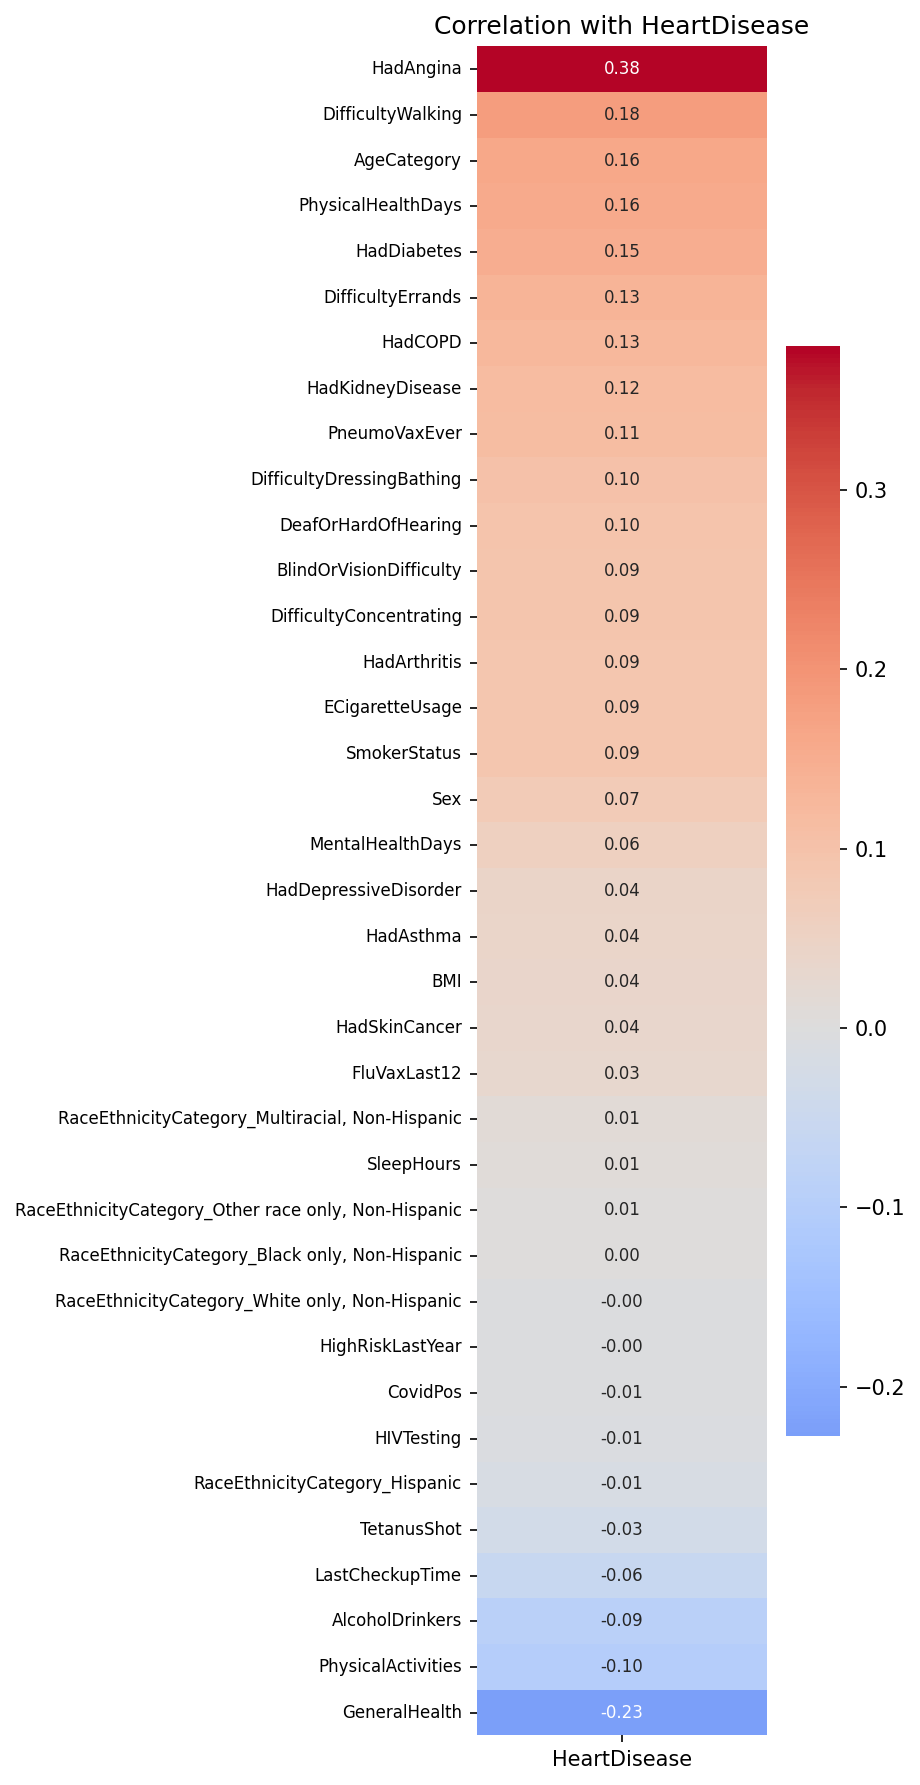

In [10]:
corr = df.select_dtypes(include=['number']).corr()

# Get correlation with target only
target_corr = corr[['HeartDisease']].sort_values(by='HeartDisease', ascending=False)
target_corr = target_corr.drop('HeartDisease')

plt.figure(figsize=(6, 12), dpi=150)

sns.heatmap(
    target_corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    annot_kws={"size": 8}
)

plt.title('Correlation with HeartDisease')
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

### Picking the Features to use

In [11]:
feature_names = ['BMI', 'DifficultyWalking', 'HadAngina', 'SleepHours']

X = df[feature_names]
y = df['HeartDisease']

## Data Splitting
Separate training and testing data

In [12]:


print("Data Splitting")
print("=" * 30)

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducible results
    stratify=y          # Maintain class proportions
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Training classes: {np.bincount(y_train)}")
print(f"Testing classes: {np.bincount(y_test)}")

Data Splitting
Training set: 132029 samples
Testing set: 33008 samples
Training classes: [117362  14667]
Testing classes: [29341  3667]


## Model Training
Teach the algorithm using training data

In [13]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)


# Create and train six different models
models = {
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "LinearSVC": LinearSVC(class_weight='balanced', max_iter=500),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model on imputed data
    model.fit(X_train_imputed, y_train)
    trained_models[name] = model
    
    print(f"✅ {name} training completed!")


Training Decision Tree...
✅ Decision Tree training completed!

Training Logistic Regression...
✅ Logistic Regression training completed!

Training Random Forest...
✅ Random Forest training completed!

Training LinearSVC...
✅ LinearSVC training completed!

Training Neural Network...
✅ Neural Network training completed!

Training Gradient Boosting...
✅ Gradient Boosting training completed!


## Model Evaluation
Test performance on unseen data

In [14]:
# Model Evaluation
print("Model Evaluation")
print("=" * 30)

results = {}

model = SVC(probability=True)

# Use imputed test set for prediction (models were trained on imputed data)
for name, model in trained_models.items():
    # Make predictions on imputed test data
    # y_pred = model.predict(X_test_imputed)
    # y_probs = model.predict_proba(X_test_imputed)[:, 1]
    # y_pred = (y_probs > 0.3).astype(int)

    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_imputed)[:, 1]
        y_pred = (y_probs > 0.65).astype(int)
    else:
        y_pred = model.predict(X_test_imputed)  # fallback

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
    
    # Detailed classification report (explicit target names)
    print("\nDetailed Performance:")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

# Compare models
print("\n📊 Model Comparison:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.3f}")
    
best_model = max(results, key=results.get)
print(f"\n🏆 Best performing model: {best_model}")



Model Evaluation

Decision Tree Results:
Accuracy: 0.836 (83.6%)

Detailed Performance:
              precision    recall  f1-score   support

          No       0.92      0.89      0.91     29341
         Yes       0.30      0.37      0.33      3667

    accuracy                           0.84     33008
   macro avg       0.61      0.63      0.62     33008
weighted avg       0.85      0.84      0.84     33008


Logistic Regression Results:
Accuracy: 0.891 (89.1%)

Detailed Performance:
              precision    recall  f1-score   support

          No       0.93      0.95      0.94     29341
         Yes       0.51      0.40      0.45      3667

    accuracy                           0.89     33008
   macro avg       0.72      0.67      0.69     33008
weighted avg       0.88      0.89      0.89     33008


Random Forest Results:
Accuracy: 0.868 (86.8%)

Detailed Performance:
              precision    recall  f1-score   support

          No       0.91      0.94      0.93     29341
 

## Model Interpretation
Understand what the model learned

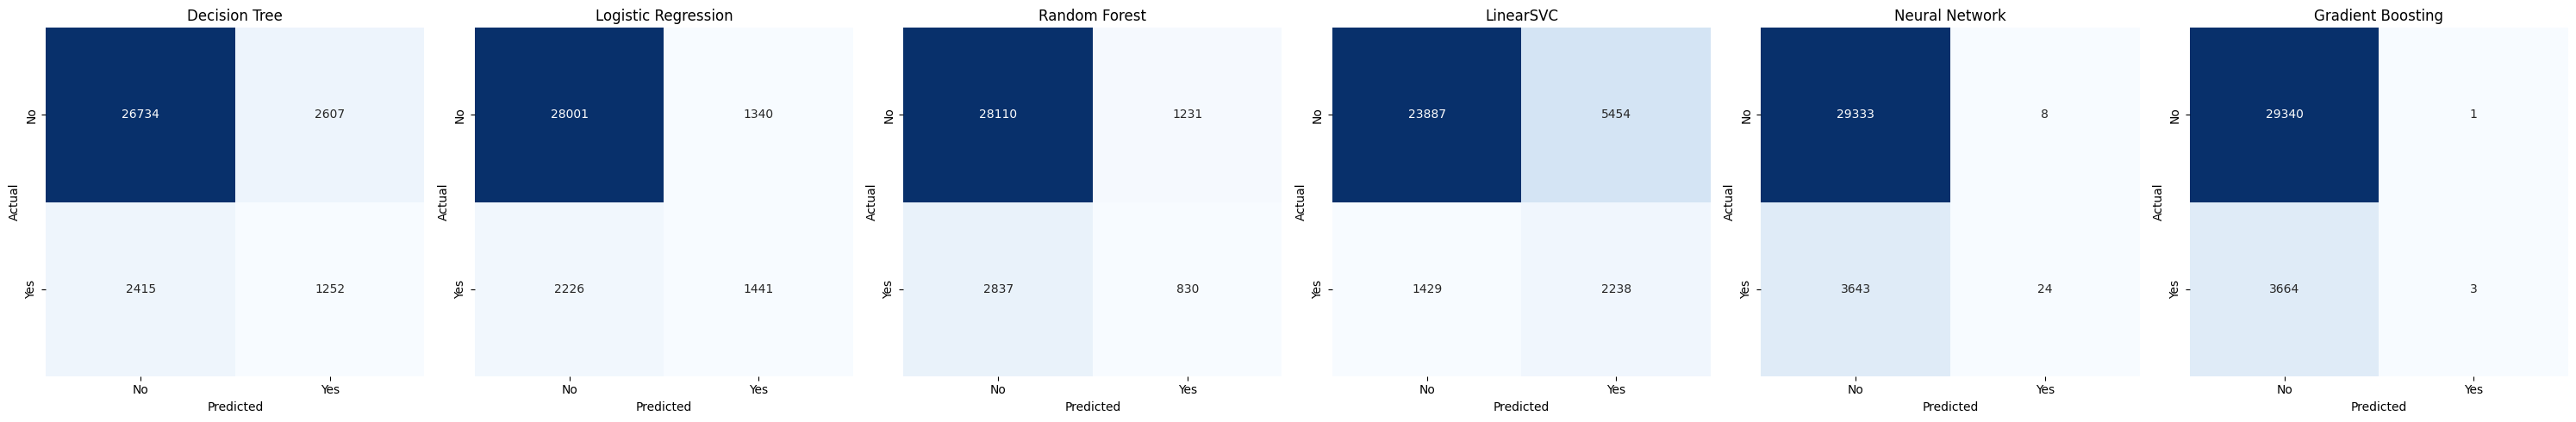

In [15]:
n_models = len(trained_models)

plt.figure(figsize=(5 * n_models, 5))

for i, (name, model) in enumerate(trained_models.items(), 1):
    
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_imputed)[:, 1]
        y_pred = (y_probs > 0.70).astype(int)
    else:
        y_pred = model.predict(X_test_imputed)

    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(1, n_models, i)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['No', 'Yes'],
        yticklabels=['No', 'Yes']
    )

    plt.title(name)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

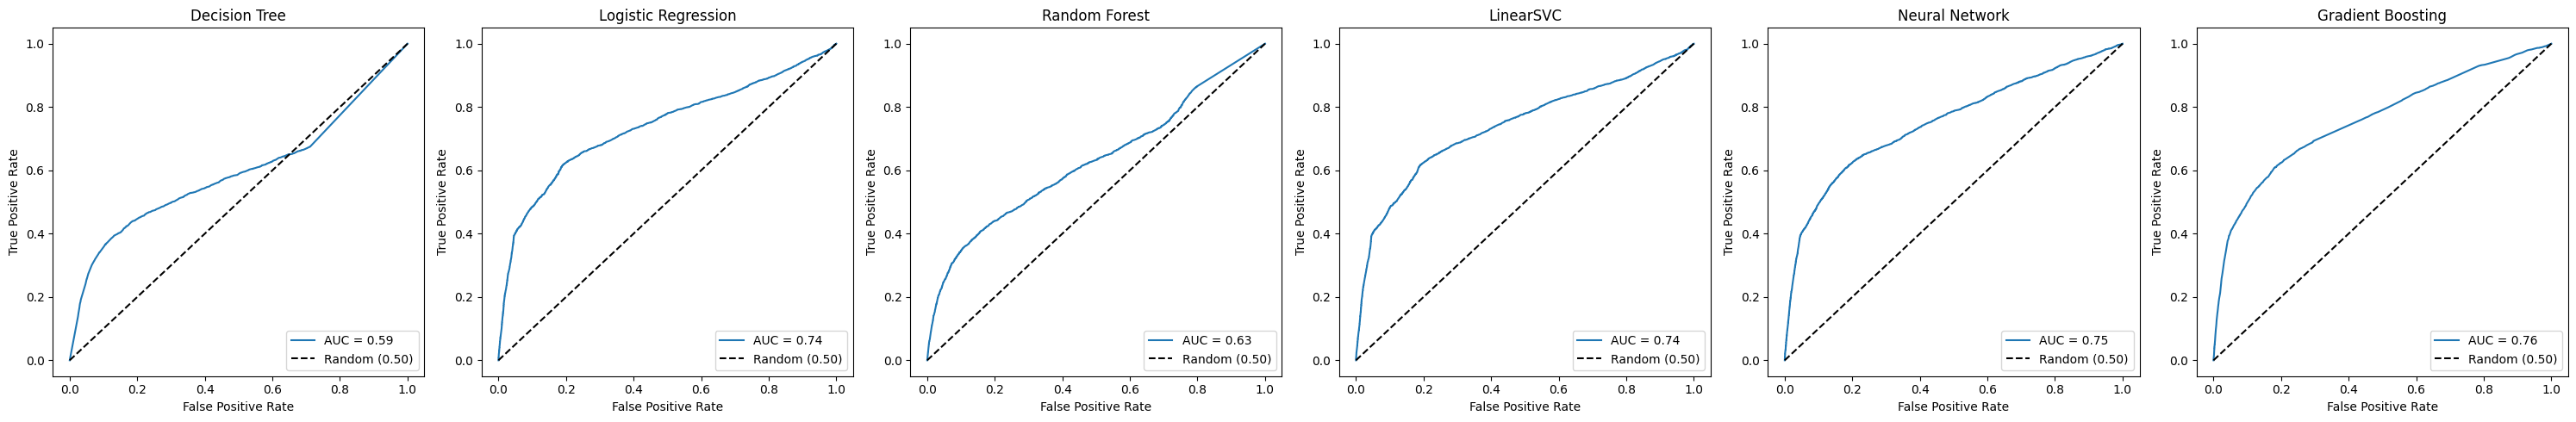

In [16]:
n_models = len(trained_models)

plt.figure(figsize=(5 * n_models, 5))

for i, (name, model) in enumerate(trained_models.items(), 1):

    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_imputed)[:, 1]
    else:
        y_probs = model.decision_function(X_test_imputed)

    auc = roc_auc_score(y_test, y_probs)
    fpr, tpr, _ = roc_curve(y_test, y_probs)

    plt.subplot(1, n_models, i)
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--', label='Random (0.50)')
    plt.title(name)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')

plt.tight_layout()
plt.show()